In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('ipl_matches_100.csv', encoding='latin1',engine='python')

# Inspect the data
print(df.head())
print(df.info())
print(df.describe(include='all'))

   ï»¿match_id team1 team2 toss_winner match_winner      venue  season
0            1    MI   SRH         RCB           MI  Bangalore    2021
1            2    MI    DC         RCB          KKR  Bangalore    2021
2            3    MI   SRH         CSK           DC  Hyderabad    2018
3            4   KKR   RCB         CSK           MI  Hyderabad    2020
4            5   KKR   CSK         CSK          RCB    Kolkata    2022
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ï»¿match_id   100 non-null    int64 
 1   team1         100 non-null    object
 2   team2         100 non-null    object
 3   toss_winner   100 non-null    object
 4   match_winner  100 non-null    object
 5   venue         100 non-null    object
 6   season        100 non-null    int64 
dtypes: int64(2), object(5)
memory usage: 5.6+ KB
None
        ï»¿match_id team1 team2 toss_w

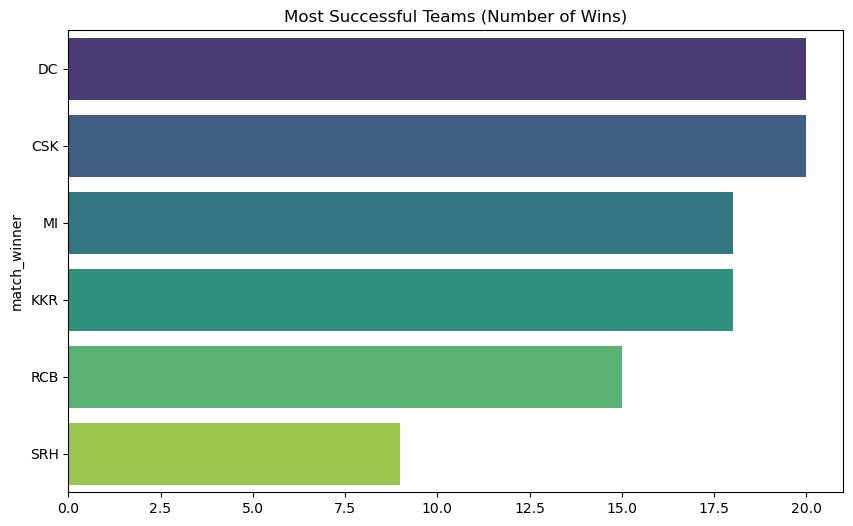

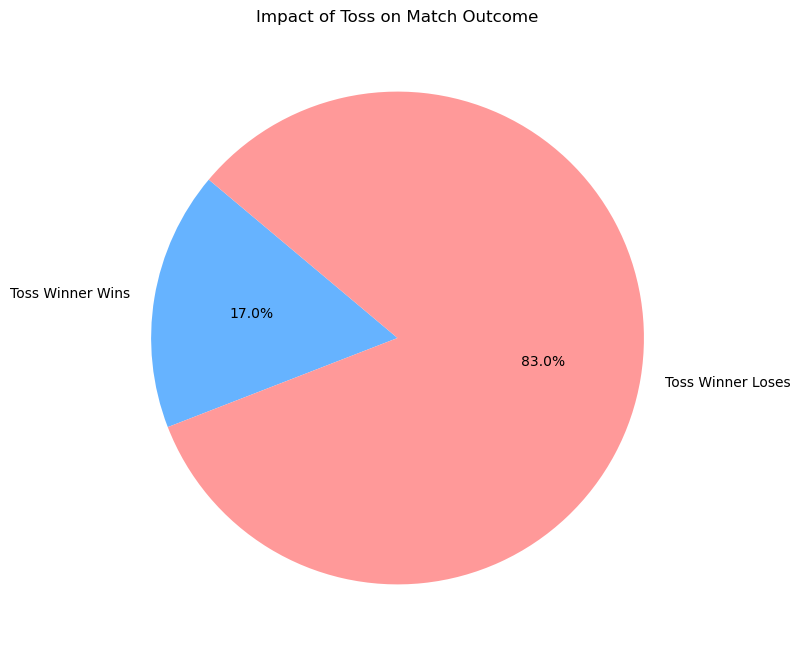

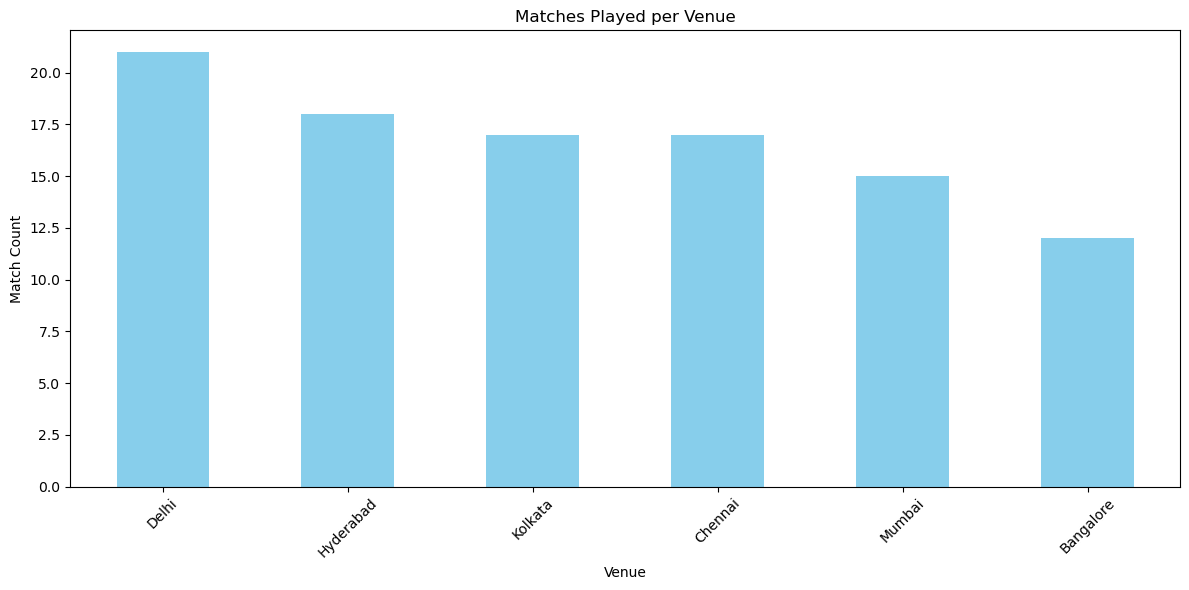

Team Wins:
 match_winner
DC     20
CSK    20
MI     18
KKR    18
RCB    15
SRH     9
Name: count, dtype: int64

Matches where Toss Winner won: 17
Matches where Toss Winner lost: 83

Venue match distribution:
 venue
Delhi        21
Hyderabad    18
Kolkata      17
Chennai      17
Mumbai       15
Bangalore    12
Name: count, dtype: int64

Wins per venue per team:
 match_winner  CSK   DC  KKR   MI  RCB  SRH
venue                                     
Bangalore     2.0  1.0  4.0  3.0  2.0  0.0
Chennai       3.0  4.0  2.0  4.0  2.0  2.0
Delhi         5.0  2.0  4.0  4.0  3.0  3.0
Hyderabad     2.0  8.0  3.0  2.0  1.0  2.0
Kolkata       6.0  2.0  3.0  2.0  2.0  2.0
Mumbai        2.0  3.0  2.0  3.0  5.0  0.0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ipl_matches_100.csv')

# 1. Most successful teams
team_wins = df['match_winner'].value_counts().sort_values(ascending=False)

# 2. Toss impact
toss_win_match_win = (df['toss_winner'] == df['match_winner']).sum()
toss_win_match_loss = len(df) - toss_win_match_win

# 3. Venue performance trends
venue_counts = df['venue'].value_counts()
venue_winners = df.groupby('venue')['match_winner'].value_counts().unstack().fillna(0)

# Create Chart 1: Most successful teams
plt.figure(figsize=(10, 6))
sns.barplot(x=team_wins.values, y=team_wins.index, hue=team_wins.index,palette='viridis' ,legend=False)
plt.title('Most Successful Teams (Number of Wins)')
plt.show()
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('most_successful_teams.png')
plt.close()

# Create Chart 2: Toss Impact
labels = ['Toss Winner Wins', 'Toss Winner Loses']
sizes = [toss_win_match_win, toss_win_match_loss]
colors = ['#66b3ff','#ff9999']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Impact of Toss on Match Outcome')
plt.show()
plt.tight_layout()
plt.savefig('toss_impact.png')
plt.close()

# Create Chart 3: Venue Trends (optional but good for 'Study venue performance')
plt.figure(figsize=(12, 6))
venue_counts.plot(kind='bar', color='skyblue')
plt.title('Matches Played per Venue')
plt.xlabel('Venue')
plt.ylabel('Match Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('venue_matches.png')
plt.close()

# Provide stats for output
print("Team Wins:\n", team_wins)
print(f"\nMatches where Toss Winner won: {toss_win_match_win}")
print(f"Matches where Toss Winner lost: {toss_win_match_loss}")
print("\nVenue match distribution:\n", venue_counts)
print("\nWins per venue per team:\n", venue_winners)


